In [1]:
# pip install xgboost scikit-learn pandas numpy matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import os, pathlib

In [3]:
# ── Cell 2: Mount Google Drive & set save path ──────────────────────────────
from google.colab import drive

drive.mount("/content/drive")

SAVE_DIR = pathlib.Path("/content/drive/MyDrive/adaptive-traffic-signal/models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Models will be saved to: {SAVE_DIR}")


Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/adaptive-traffic-signal/models


In [4]:
# ── Cell 3: Synthetic data generation ───────────────────────────────────────
np.random.seed(42)

DAYS = 30
INTERVAL_SEC = 3
STEPS_PER_DAY = (24 * 3600) // INTERVAL_SEC  # 28800 steps/day
TOTAL_STEPS = DAYS * STEPS_PER_DAY
DIRECTIONS = ["N", "S", "E", "W"]

timestamps = pd.date_range("2026-01-01", periods=TOTAL_STEPS, freq=f"{INTERVAL_SEC}s")


def traffic_volume(hour: int, is_weekend: bool) -> int:
    """Return base vehicle count per 3-second interval for a given hour."""
    if is_weekend:
        return 6 if 10 <= hour <= 20 else 2
    if 7 <= hour < 9:
        return 12  # morning rush
    elif 9 <= hour < 12:
        return 7
    elif 12 <= hour < 14:
        return 9  # lunch
    elif 14 <= hour < 17:
        return 6
    elif 17 <= hour < 20:
        return 13  # evening rush
    elif 20 <= hour < 23:
        return 4
    else:
        return 1  # night


# Direction-specific multipliers: N is busiest, W is quietest
DIRECTION_MULTIPLIERS = {"N": 1.1, "S": 0.9, "E": 1.0, "W": 0.8}

rows = []
for ts in timestamps:
    base = traffic_volume(ts.hour, ts.dayofweek >= 5)
    row = [ts] + [
        max(0, int(np.random.poisson(base * DIRECTION_MULTIPLIERS[d]))) for d in DIRECTIONS
    ]
    rows.append(row)

df = pd.DataFrame(rows, columns=["timestamp"] + DIRECTIONS)
df.set_index("timestamp", inplace=True)

print(f"Dataset shape : {df.shape}")  # (864000, 4)
print(f"Date range    : {df.index[0]}  →  {df.index[-1]}")
print(f"\nSample statistics:\n{df.describe().round(2)}")
df.head(8)


Dataset shape : (864000, 4)
Date range    : 2026-01-01 00:00:00  →  2026-01-30 23:59:57

Sample statistics:
               N          S          E          W
count  864000.00  864000.00  864000.00  864000.00
mean        5.83       4.77       5.30       4.24
std         4.97       4.18       4.57       3.77
min         0.00       0.00       0.00       0.00
25%         2.00       1.00       1.00       1.00
50%         5.00       4.00       4.00       3.00
75%         9.00       7.00       8.00       6.00
max        33.00      28.00      32.00      26.00


,N,S,E,W
timestamp,,,,
2026-01-01 00:00:00,2,1,0,0
2026-01-01 00:00:03,3,2,0,0
2026-01-01 00:00:06,0,1,0,1
2026-01-01 00:00:09,0,0,1,0
2026-01-01 00:00:12,1,0,1,0
2026-01-01 00:00:15,3,0,1,0
2026-01-01 00:00:18,1,1,1,1
2026-01-01 00:00:21,0,4,1,0


In [7]:
# ── Cell 4: Feature engineering + train on T4 GPU ───────────────────────────
WINDOW = 100  # 100 steps × 3 s = 5 min of history as input
HORIZON = 20  # predict 20 steps × 3 s = 60 s ahead


def make_features(
    df: pd.DataFrame,
    window: int = WINDOW,
    horizon: int = HORIZON,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build sliding-window feature matrix X and target matrix Y.

    X shape: (samples, window * 4 directions + 4 time features) = (N, 404)
    Y shape: (samples, 4 directions)
    """
    arr = df[DIRECTIONS].values  # (T, 4)
    X_rows, Y_rows = [], []

    for i in range(window, len(arr) - horizon):
        ts = df.index[i]

        # 400 lag features: flatten [window, 4] block
        lag_block = arr[i - window : i].flatten()

        # 4 cyclic time features
        hour = ts.hour + ts.minute / 60
        dow = ts.dayofweek
        time_feats = np.array(
            [
                np.sin(2 * np.pi * hour / 24),
                np.cos(2 * np.pi * hour / 24),
                np.sin(2 * np.pi * dow / 7),
                np.cos(2 * np.pi * dow / 7),
            ]
        )

        X_rows.append(np.concatenate([lag_block, time_feats]))
        # Target = mean density over next HORIZON steps (more stable & useful
        # for signal timing than a single noisy future sample)
        Y_rows.append(arr[i : i + horizon].mean(axis=0))

    return (
        np.array(X_rows, dtype=np.float32),
        np.array(Y_rows, dtype=np.float32),
    )


print("Building feature matrix (this takes ~2–3 min on Colab)...")
X, Y = make_features(df)
print(f"X: {X.shape}   Y: {Y.shape}")  # X: (863780, 404)  Y: (863780, 4)

# Time-ordered 85/15 split — no shuffle to prevent data leakage
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.15, shuffle=False)
print(f"Train: {X_tr.shape}   Test: {X_te.shape}")

# ── Train one XGBRegressor per direction ────────────────────────────────────
models: dict[str, XGBRegressor] = {}
maes: dict[str, float] = {}

for i, direction in enumerate(DIRECTIONS):
    print(f"\n[{direction}] Training...")
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        device="cuda",  # T4 GPU on Colab
        tree_method="hist",  # required for GPU
        random_state=42,
    )
    model.fit(
        X_tr,
        Y_tr[:, i],
        eval_set=[(X_te, Y_te[:, i])],
        verbose=50,
    )
    preds = model.predict(X_te)
    mae = mean_absolute_error(Y_te[:, i], preds)
    models[direction] = model
    maes[direction] = mae
    print(f"  MAE ({direction}): {mae:.4f} vehicles")

print("\n" + "─" * 40)
print("RESULTS SUMMARY")
print("─" * 40)
TARGET_MAE = 2.0
all_pass = True
for d, m in maes.items():
    status = "✓ PASS" if m < TARGET_MAE else "✗ FAIL"
    if m >= TARGET_MAE:
        all_pass = False
    print(f"  {d}:  MAE = {m:.4f}   {status}  (target < {TARGET_MAE})")
print("─" * 40)
print(
    f"Overall: {'ALL PASS ✓' if all_pass else 'SOME FAILED ✗ — consider more training data or tuning'}"
)

Building feature matrix (this takes ~2–3 min on Colab)...
X: (863880, 404)   Y: (863880, 4)
Train: (734298, 404)   Test: (129582, 404)

[N] Training...
[0]	validation_0-rmse:4.64197
[50]	validation_0-rmse:0.79294
[100]	validation_0-rmse:0.65526
[150]	validation_0-rmse:0.64416
[200]	validation_0-rmse:0.64124
[250]	validation_0-rmse:0.63995
[299]	validation_0-rmse:0.63936
  MAE (N): 0.4501 vehicles

[S] Training...
[0]	validation_0-rmse:3.81010
[50]	validation_0-rmse:0.69226
[100]	validation_0-rmse:0.58438
[150]	validation_0-rmse:0.57609
[200]	validation_0-rmse:0.57479
[250]	validation_0-rmse:0.57389
[299]	validation_0-rmse:0.57292
  MAE (S): 0.4062 vehicles

[E] Training...
[0]	validation_0-rmse:4.20085
[50]	validation_0-rmse:0.73401
[100]	validation_0-rmse:0.62217
[150]	validation_0-rmse:0.61327
[200]	validation_0-rmse:0.61120
[250]	validation_0-rmse:0.61004
[299]	validation_0-rmse:0.60942
  MAE (E): 0.4307 vehicles

[W] Training...
[0]	validation_0-rmse:3.37564
[50]	validation_0-rmse:

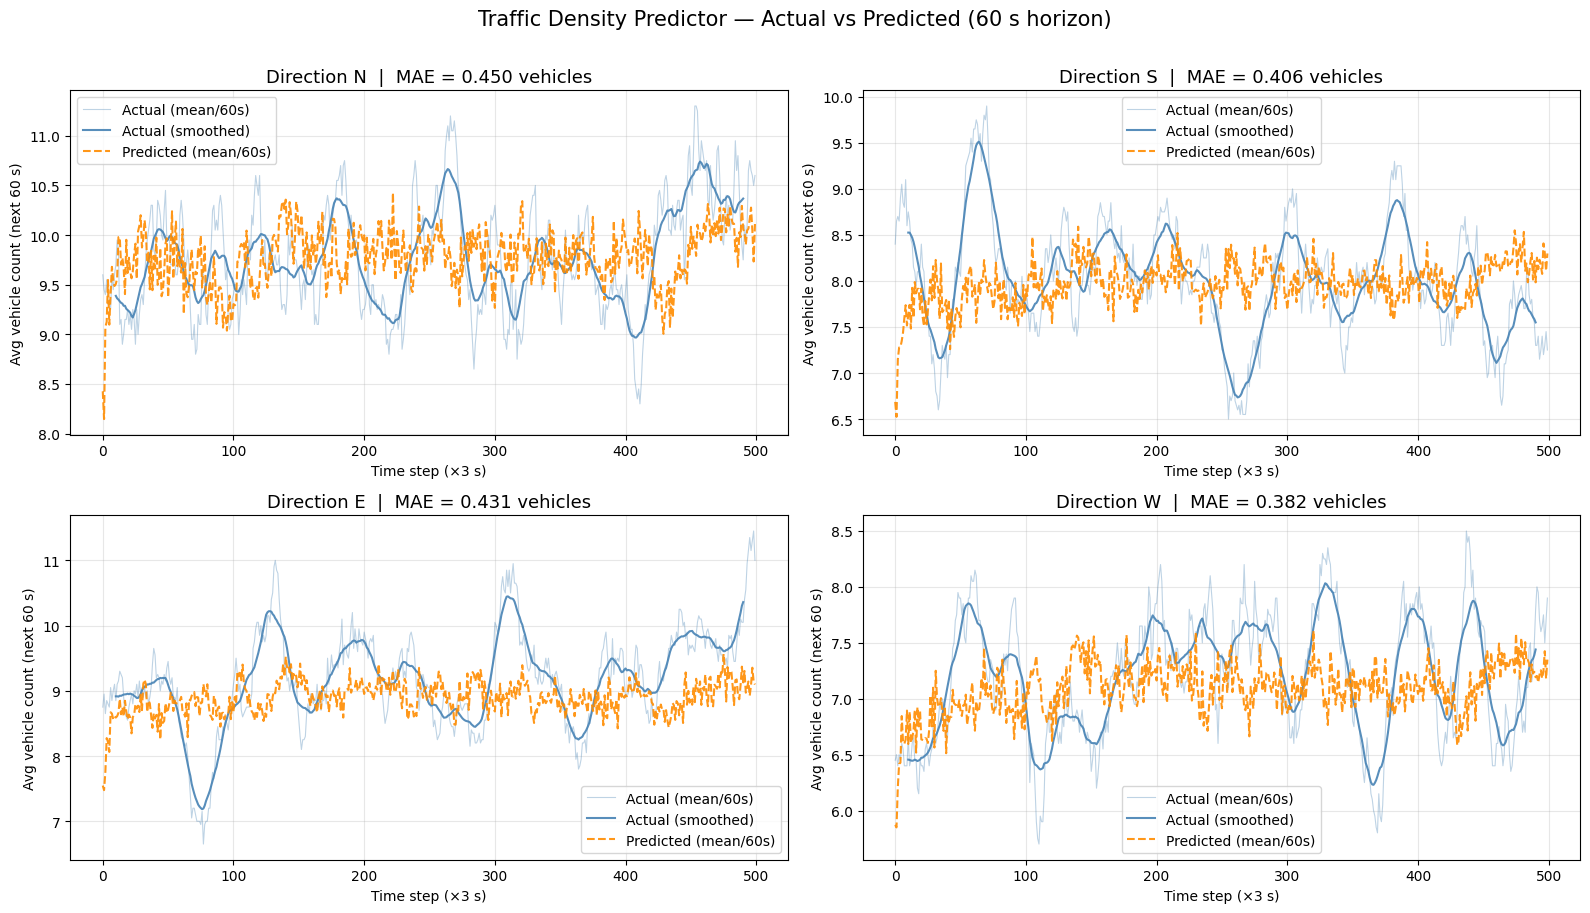

Plot saved: /content/drive/MyDrive/adaptive-traffic-signal/models/density_predictor_eval.png

Saving models to Google Drive...
  ✓  density_predictor_N.ubj  (1292.5 KB)
  ✓  density_predictor_S.ubj  (1367.0 KB)
  ✓  density_predictor_E.ubj  (1263.3 KB)
  ✓  density_predictor_W.ubj  (1284.1 KB)

─────────────────────────────────────────────────────
All models saved to Google Drive:
  /content/drive/MyDrive/adaptive-traffic-signal/models

Next steps:
  1. Download the 4 .ubj files from Google Drive
  2. Place them in your local  models/  directory:
       models/density_predictor_N.ubj
       models/density_predictor_S.ubj
       models/density_predictor_E.ubj
       models/density_predictor_W.ubj

  3. Run integration with prediction/predictor.py

─────────────────────────────────────────────────────


In [8]:
# ── Cell 5: Evaluation plots + save models to Google Drive ──────────────────
PLOT_SAMPLES = 500

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

SMOOTH_WIN = 20  # rolling window for raw actual line (matches horizon)

for i, direction in enumerate(DIRECTIONS):
    actual_raw = Y_te[:PLOT_SAMPLES, i]  # mean-over-horizon targets
    actual_smooth = pd.Series(actual_raw).rolling(SMOOTH_WIN, center=True).mean()
    preds = models[direction].predict(X_te[:PLOT_SAMPLES])

    axes[i].plot(
        actual_raw, label="Actual (mean/60s)", alpha=0.35, linewidth=0.8, color="steelblue"
    )
    axes[i].plot(
        actual_smooth, label="Actual (smoothed)", alpha=0.9, linewidth=1.5, color="steelblue"
    )
    axes[i].plot(
        preds,
        label="Predicted (mean/60s)",
        alpha=0.9,
        linewidth=1.5,
        linestyle="--",
        color="darkorange",
    )
    axes[i].set_title(
        f"Direction {direction}  |  MAE = {maes[direction]:.3f} vehicles",
        fontsize=13,
    )
    axes[i].legend()
    axes[i].set_xlabel("Time step (×3 s)")
    axes[i].set_ylabel("Avg vehicle count (next 60 s)")
    axes[i].grid(True, alpha=0.3)

plt.suptitle(
    "Traffic Density Predictor — Actual vs Predicted (60 s horizon)",
    fontsize=15,
    y=1.01,
)
plt.tight_layout()

eval_plot_path = SAVE_DIR / "density_predictor_eval.png"
plt.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved: {eval_plot_path}")

# ── Save each model ──────────────────────────────────────────────────────────
print("\nSaving models to Google Drive...")
for direction, model in models.items():
    save_path = SAVE_DIR / f"density_predictor_{direction}.ubj"
    model.save_model(str(save_path))
    size_kb = save_path.stat().st_size / 1024
    print(f"  ✓  density_predictor_{direction}.ubj  ({size_kb:.1f} KB)")

print(f"""
─────────────────────────────────────────────────────
All models saved to Google Drive:
  {SAVE_DIR}

Next steps:
  1. Download the 4 .ubj files from Google Drive
  2. Place them in your local  models/  directory:
       models/density_predictor_N.ubj
       models/density_predictor_S.ubj
       models/density_predictor_E.ubj
       models/density_predictor_W.ubj

  3. Run integration with prediction/predictor.py

─────────────────────────────────────────────────────""")